### CC3 : TP Calcul Scientifique évalué
### December 19, 2024

On a pour condition limite Neumann donc des dérivées nulles au bords. $$
\begin{cases}
    -u''(x)+ 2u(x) + cu'(x)=f(x) & \text{pour } x\in [0,1],\\
    \quad u'(0)=u'(1), \text{(condition de Neumann)},
\end{cases} 
$$

In [434]:
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags
import sympy as sy
from numpy import linspace, ones
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.pylab import *
from time import time
from mpl_toolkits import mplot3d
from scipy.fftpack import rfft, irfft, dst, dct, idst

### 1.1 Solution exacte

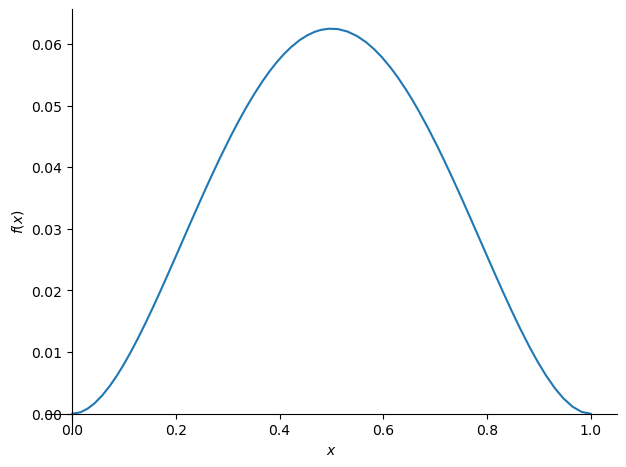

u(x) = 


(-x**2 + x)**2

u'(x) = 


(2 - 4*x)*(-x**2 + x)

u'(0) = 


0

u'(1) = 


0

f(x) = 


3*(2 - 4*x)*(-x**2 + x) + 2*(-x**2 + x)**2 - 2*(2*x**2 - 2*x + (2*x - 1)**2)

In [435]:
x = sy.symbols('x')


u = (x-x**2)**2
c = 3
f = -u.diff(x, 2) + 2*u + c * u.diff(x, 1)
sy.plot(u,(x, 0, 1))



# Condition de Neumann dérivée de u'(0) = u'(1) = 0
print("u(x) = ")
display(u)
print("u'(x) = ")
display(u.diff(x))
print("u'(0) = ")
display(u.diff(x).subs(x,0))
print("u'(1) = ")
display(u.diff(x).subs(x,1)) 

print("f(x) = ")
display(f)
f = sy.lambdify(x, f)

u = sy.lambdify(x, u)




### 1.2 Aprroximation différence finie

On introduit la discrétisation uniforme du segment $]0,1[$ par 
$$
x_i=i h, \quad i=0\cdots N-1,
$$
avec $h=\frac 1 {N-1}$.
Pour $i=0$ à $N-1$, on va approcher l'équation $-u''(x_i)+2 * u(x_i) + c * u'(x_i)=f(x_i)$. On note $u_i\sim u(x_i)$ et $f_i=f(x_i)$.
Pour $i=0$ et $i=N-1$, on introduit alors $u_{-1}$ et $u_{N}$ qu'il convient d'éliminer par la condition limite de Neuman homogène. On remarque que la différence centrée qui approche la dérivée ($u'(x)=\frac {2*(u(x+h)-u(x-h))} {2hc}$) permet d'écrire
$$
u_{-1}=u_1,\quad u_{N}=u_{N-2}.
$$
On a alors le système linéaire
$$
\left \{\begin {align}
&u_{-1}=u_1\\
&\frac {2(-u_{-1}+2u_0-u_1)}{h^2c}+u_0=f_0\\
&\frac {2(-u_{0}+2u_1-u_2)}{h^2c}+u_1=f_1\\
&\frac {2(-u_{1}+2u_2-u_3)}{h^2c}+u_2=f_2\\
&\cdots\\
&\frac {2(-u_{i-1}+2u_i-u_{i+1})}{h^2c}+u_i=f_i\\
&\cdots\\
&\frac {2(-u_{N-2}+2u_{N-1}-u_{N})}{h^2c}+u_{N-1}=f_{N-1}\\
&u_{N}=u_{N-2}.
\end {align}\right .
$$
En éliminant la première et la dernière equation substituées dans la deuxième et avant-dernière equation, il vient le système de $N$ inconnues $U=(u_0,\cdots,u_{N-1})^t$ suivant:
$$
A U=F,\quad F=\left (f_0,\cdots,f_{N-1}\right)^t,
$$
avec 
$$
A=\frac 1 {h^2}\left (\begin {matrix}&4&-4&0&\cdots&0\\
&-2&4&-2&0&\cdots\\
&0&-2&4&-2&0 \\
&-&-&-&-&-\\
&0&\cdots&0&-4&4\end{matrix}\right )+Id
$$
Par soucis de symétrie dans le système et parce que cela est pertinent pour les méthodes de résolution de système linéaire, on symétrise le système en divisant par $4$ la première et dernière équation du système. On obtient alors le système:
$$
A U=F,\quad F=\left(\frac {f_{0}}2,f_1,\cdots,f_{N-2},\frac {f_{N-1}}2\right)^t,
$$
avec 
$$
A=\frac 1 {h^2}\left (\begin {matrix}&1&-1&0&\cdots&0\\
&-2&4&-2&0&\cdots\\
&0&-2&4&-2&0 \\
&-&-&-&-&-\\
&0&\cdots&0&-1&1\end{matrix}\right )+\left (\begin {matrix}&\frac 1 4&0& &\cdots&0\\
&0&1&0& &\cdots\\
&&0&1&0& \\
&-&-&-&-&-\\
& &\cdots& &0&\frac 1 4\end{matrix}\right )
$$


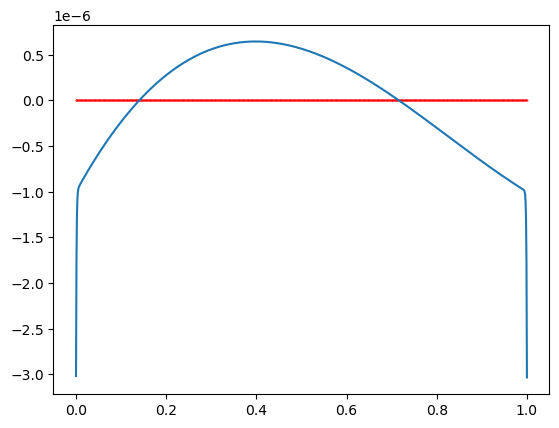

In [436]:
# N le nombre de points de la discrétisation
N=1000
# le pas h
h=1/(N-1) 
# construction du vecteur de discrétisation
X=linspace(0,1,N)

#construction du second membre du systeme
F=f(X)

F[0]=0.5*F[0]
F[N-1]=0.5*F[N-1]

#construction de la matrice en systeme creux

#construction des diagonales
D0=(2/h**2 * c+1)*ones(N) 
D0[0]=1/4*D0[0]
D0[N-1]=1/4*D0[N-1]
D1=-1/h**2*ones(N) * 2
A=spdiags(D0,[0],N,N)+spdiags(D1,[1],N,N)+spdiags(D1,[-1],N,N)

#résolution
U=spsolve(A,F)
#affichage solution approchée
plot(X,U)
#affichage solution exacte
#plot(X, u(X))
#On rajoute les points de discrétisation sur l'axe des abscisses.
scatter(X,0*X,[0.1],'red')

### 1.3 Méthode spectrale

pour $c = 0$ on a le probleme 
$$
\begin{cases}
    -u''(x)+ 2u(x)=f(x) & \text{pour } x\in [0,1],\\
    \quad u'(0)=u'(1), \text{(condition de Neumann)},
\end{cases} 
$$

Une base d'approximation de dimension n induite par méthode de Galerkine de type spectrale pour des conditions limites de Neumann donc satisfaisant une dérivée nulle aux extrémités, une base en cosinus est adaptée. On remarque que la grille de pas $dx$ est placée au milieu des segments $N$ segments de longueur $dx$ qui couvrent l'intervalle $[0,L]$. Ansi on évalue la fonction en $\frac {dx} 2$ puis par pas de $dx$  avant d'en calculer la transformée de Fourier "dct". La base construite est $\phi_0=\frac 1 {2N}$, $\phi_1(x)=\frac 1 {N} \cos(\pi\frac x L)$, $\phi_2(x)=\frac 1 {N} \cos(\pi 2\frac x L)$, $\cdots$, $\phi_{N-2}(x)=\frac 1 {N} \cos(\pi(N-2)\frac x L)$, $\phi_{N-1}(x)=\frac 1 {N} \cos(\pi(N-1)\frac x L)$.

Contrairement à la fonction "irfft" qui est bien la transformée inverse de la fonction "rfft", la fonction "idct" doit être renormalisée par $\frac 1 {2N}$.

fchap=


array([ 2.46665000e+00, -5.03319307e+00, -2.54329845e+01, -4.58122748e-01,
       -6.04899975e+00, -1.59252673e-01, -2.60738210e+00, -7.84692023e-02,
       -1.40889693e+00, -4.52086997e-02, -8.49942351e-01, -2.81385643e-02,
       -5.39413624e-01, -1.79958322e-02, -3.43366579e-01, -1.12226314e-02,
       -2.05096933e-01, -6.17922226e-03, -9.62583401e-02, -1.97561867e-03])

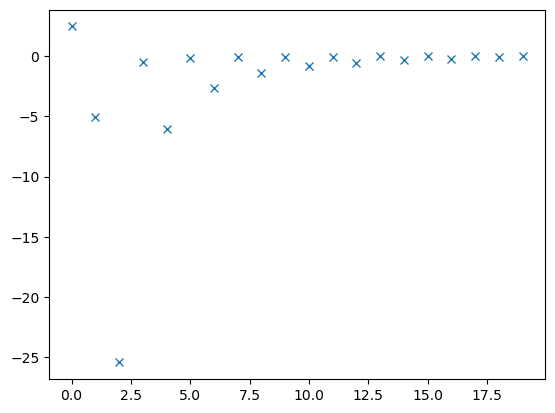

In [437]:
from scipy.fftpack import rfft, irfft
x = sy.symbols('x')
u = (x-x**2)**2
# c = 0
f = -u.diff(x, 2) + 2*u

f = sy.lambdify(x, f)
u = sy.lambdify(x, u)



N=20
L=1
dx=L/N
X=np.linspace(0,L-dx,N)
fchap=dct(f(X))
plt.plot(fchap,'x')
print('fchap=')
display(fchap)


- Ecrire le problème approché au limite dans cet espace 
    d'approximation (rédaction Markdown).

On cherche $u_n\in V_n$ tel que
$$
    -u_n''(x)+2u_n(x)=\sum_{k=0}^{n-1}\hat{u}_k(\lambda_k+2)\phi_k(x)=\sum_{k=0}^{n-1}\hat{f}_k\phi_k(x),
$$
où $\hat{f}_k$ sont les coefficients de Fourier de $f$, $\hat{u}_k$ sont les coefficients de Fourier de $f$ et $\lambda_k$ sont les valeurs propres de $-\partial_x^2$ dans $V_n$:
$$
   -\phi_k''(x)= \lambda_k \phi_k(x).
$$
On identifie les coefficients de Fourier des deux membres de l'équation précédente pour obtenir :
$$
    \hat{u}_k=\frac{\hat{f}_k}{\lambda_k+2}.
$$
Ainsi, la solution approchée est donnée par
$$
    u_n(x)=\sum_{k=0}^{n-1}\frac{\hat{f}_k}{\lambda_k+2}\phi_k(x).
$$

On a bien supperposition de la solution exacte et de la solution approchée
Erreur= 0.0014424283746042594


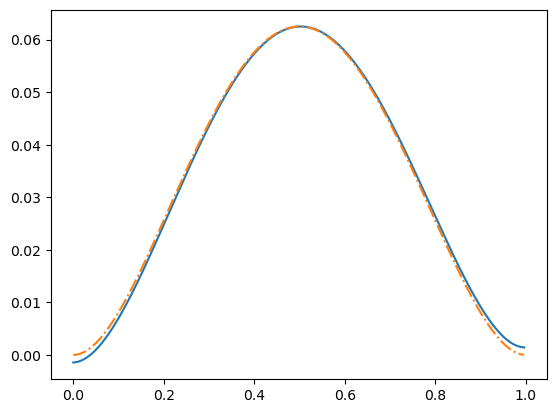

In [438]:
from scipy.fftpack import dct, idct
N=300
L=1
dx=L/N
X=np.linspace(0,L-dx,N)
Fchap=dct(f(X))

kk=np.arange(N)

lammb= (np.pi * kk  / L) ** 2


Uchap= Fchap/(lammb + 2)


#uchap=fchap/(lambda_k + 2)
U=0.5*idct(Uchap)/N # fourier inverse
plt.plot(X,U)
plt.plot(X,u(X),'-.') # u = fct exacte
print('On a bien supperposition de la solution exacte et de la solution approchée')
print('Erreur=',max(abs(U-u(X))))

# Problème d'évolution 1D

## 3.1 Solution exacte

In [439]:
x , t = sy.symbols('x t')


u = (x-x**2)**2 * t
fct = lambda x: np.cos(np.pi * x / L) * (x) * (L - x)
c = 3
#f = -u.diff(x, 2) + 2*u + c * u.diff(x, 1)
f = u.diff(x, 1) -u.diff(x, 2) + 2*u + c * u.diff(x, 1)

#sy.plot(f,(x, 0, 1))



# Condition de Neumann dérivée de u'(0) = u'(1) = 0
print("u(x) = ")
display(u)
print("u'(x) = ")
display(u.diff(x))
print("u'(0) = ")
display(u.diff(x).subs(x,0))
print("u'(1) = ")
display(u.diff(x).subs(x,1)) 

print("f(x) = ")
display(f)
f = sy.lambdify(x, f)

u = sy.lambdify(x, u)


u(x) = 


t*(-x**2 + x)**2

u'(x) = 


t*(2 - 4*x)*(-x**2 + x)

u'(0) = 


0

u'(1) = 


0

f(x) = 


4*t*(2 - 4*x)*(-x**2 + x) + 2*t*(-x**2 + x)**2 - 2*t*(2*x**2 - 2*x + (2*x - 1)**2)

## 3.3 Méthode spectrale

### 3.3.1
Pour une certaine condition au limite homogène (Dirichlet, Neumann, ou périodique), en un problème approché, écrit pour chaque composante d'une base en Fourier, sous la forme
$$
\partial_t \hat{\textbf{u}}_k(t)+\lambda_k\hat{\textbf{u}}_k(t)=\hat{f}_k(t),
$$
où $\lambda_k$ dépend de la condition limite choisie (ici Neumann).

On applique la formule de Duhamel entre les instants $t+dt$ et $t$ où $dt>0$:
$$
\hat{\textbf{u}}_k(t+dt)=\hat{\textbf{u}}_k(t)e^{-\lambda_k dt}+\int_t^{t+dt} e^{-\lambda_k (t+dt-s)}\hat{f}_k(s)\,ds.
$$
On appliquera cette formule pour $t=0$ puis $t=dt,2dt,3dt,\cdots$.  

### 3.2.2
La contribution du terme source sera évaluée par une formule de quadrature (approximation de l'intégrale) et sa précision repose sur la petitesse de $dt$. On prendra par exemple la formule de quadrature du point milieu:
$$
\int_t^{t+dt} e^{-\lambda_k (t+dt-s)}\hat{f}_k(s)\,ds\sim dt e^{-\lambda_k (\frac {dt} 2)}\hat{f}_k(t+\frac {dt} 2).
$$

### 3.3.3

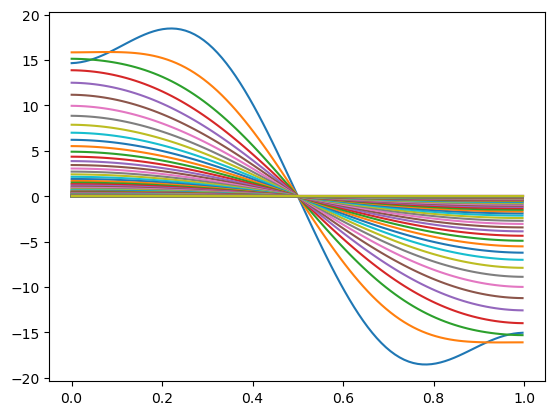

In [440]:
L = 1
N = 100
X=np.linspace(0,L-dx,N)

fct = lambda x: np.cos(np.pi * x / L) * (x) * (L - x)
U0 = fct(X)

Fchap=dct(U0)

kk=np.arange(N)

lammb= (np.pi * kk  / L) ** 2

for t in np.arange(0.01, 1, 0.01):

    #Duhamel
    Uchap = np.exp(-(lammb + 2) * t) * Fchap

    U = idct(Uchap)

    plot(X, U)




### Les conditions de Neumann sont bien respectées au bords.


### 3.3.4

TypeError: _lambdifygenerated() takes 1 positional argument but 2 were given

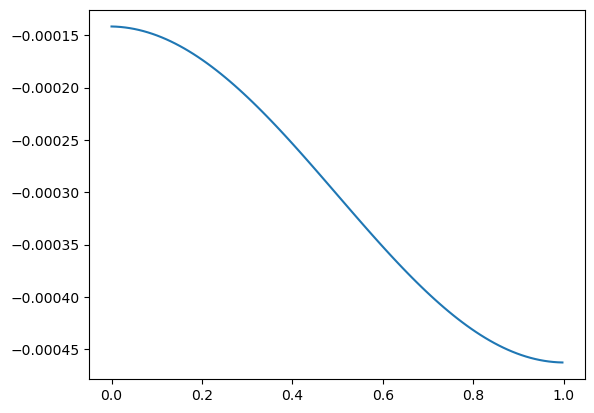

In [441]:
L = 1
N = 100
X=np.linspace(0,L-dx,N)

fct = lambda x: np.cos(np.pi * x / L) * (x) * (L - x)
U0 = fct(X)

Fchap=dct(U0)

kk=np.arange(N)

lammb= (np.pi * kk  / L) ** 2

t = 1

#Duhamel
Uchap = np.exp(-(lammb + 2) * t) * Fchap

U = idct(Uchap)

plot(X, U)


plot(X, f(X, t))

